In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit
from scipy.stats import norm
import random
import math

In [3]:
import pandas as pd 
import h5py

h5 = h5py.File('sample_2e7_design_precessing_higherordermodes_3detectors.h5','r')

d = {i: h5[i][:10**5] for i in h5.keys()} #downsample the data cause too many
df = pd.DataFrame(data=d)
df

,chi1x,chi1y,chi1z,chi2x,chi2y,chi2z,dec,det,iota,mtot,psi,q,ra,snr,z
0,-0.307201,0.276165,-0.430760,-0.161114,-0.092334,-0.414647,-0.329671,0,1.809310,906.803562,1.286031,0.624780,-3.116784,0.822509,2.139659
1,-0.734712,-0.498493,-0.298162,0.057532,-0.844992,0.014708,0.526740,0,0.820820,59.102112,0.934308,0.986650,1.360291,1.093237,2.438707
2,-0.057831,-0.703796,-0.354512,-0.215538,0.016323,0.130543,0.315799,0,2.008206,44.602750,1.535520,0.286199,0.079973,1.305398,1.869461
3,0.015260,-0.202467,-0.492768,-0.237033,-0.365363,-0.876192,0.432105,0,2.018398,534.378032,3.064086,0.538882,-1.780558,9.112974,0.428061
4,-0.016731,0.007848,0.005007,0.147519,0.231879,0.086716,-0.458711,1,2.037363,573.821705,0.752211,0.846310,2.789289,17.525534,0.772609
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,-0.710484,0.203788,-0.030539,-0.194861,0.014570,-0.054834,-0.239913,0,1.905192,326.220322,1.473113,0.802986,1.273264,1.669939,1.901201
99996,0.804222,0.086352,0.550408,0.181968,0.824057,0.412858,0.195437,0,1.920145,403.949547,0.184597,0.386258,-1.279446,6.605718,1.491419
99997,0.652722,-0.022264,0.132145,0.272847,0.381442,0.773596,-0.584279,1,2.637491,884.399749,1.601521,0.722733,0.444194,14.355243,0.735589
99998,-0.134977,0.016409,-0.207572,-0.100090,0.117877,0.054799,0.754165,1,1.147342,949.832616,0.060168,0.459489,-0.415330,12.521137,0.394833


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.linear_model import LogisticRegression

data = df
#80% of the data as tranining dataset and leaving the other 20% as a validation set
Xtrain, Xtest = train_test_split(data,train_size=0.80)

In [5]:
X_train = Xtrain.drop(['det','snr'],axis=1) #delete the 'det' and 'srn' column
X_test = Xtest.drop(['det','snr'],axis=1) #delete the 'det' and 'srn' column
keys = list(X_test.keys())

## Random Forest

In [6]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

K = 5 # Do 5-fold cross validation
n = np.arange(5,51,5)

ranfor = RandomForestClassifier(10)
grid = GridSearchCV(ranfor, {'n_estimators': n}, cv = K, scoring='neg_mean_squared_error') # Try each degree with K-folds
grid.fit(X_train,Xtrain['det'].to_numpy())
opt_n = grid.best_params_['n_estimators']
print('Optimal n_estimators through cross validation: %i' % opt_n)

Optimal n_estimators through cross validation: 50


In [19]:
ranfor = RandomForestClassifier(opt_n)
ranfor.fit(X_train,Xtrain['det'])
y_pred = ranfor.predict(X_test)

In [20]:
from sklearn.metrics import confusion_matrix, roc_curve, precision_recall_curve

print('score: ', ranfor.score(X_test,Xtest['det']))
C = confusion_matrix(Xtest['det'], y_pred)
print(C)

score:  0.96545
[[16809   269]
 [  422  2500]]


### ROC curve

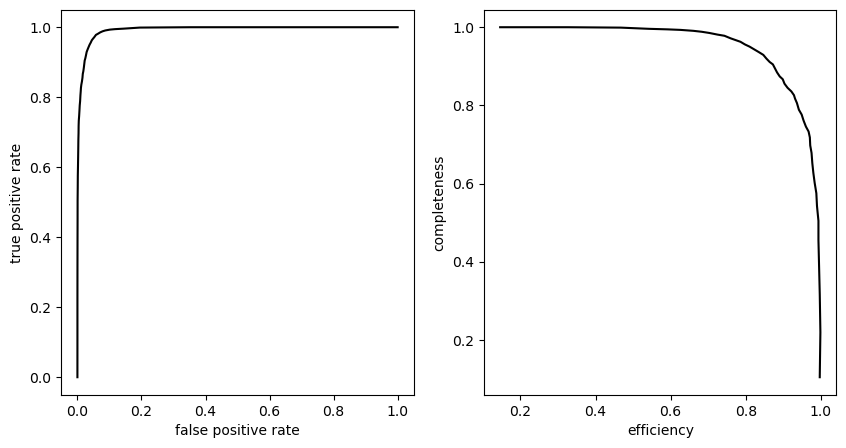

In [21]:
from astroML.utils import completeness_contamination

y_prob = ranfor.predict_proba(X_test)[:,1]
fpr, tpr, th = roc_curve(Xtest['det'], y_prob)
#precision, recall, th2 = precision_recall_curve(Xtest['det'], y_prob)

thresholds = np.linspace(0, 1, 50001)[:-1]
comp = np.zeros_like(thresholds)
cont = np.zeros_like(thresholds)
for i, t in enumerate(thresholds):
    y_pred = (y_prob >= t)
    comp[i], cont[i] = completeness_contamination(y_pred, Xtest['det'])

fig, ax = plt.subplots(1,2, figsize=(10,5))
ax[0].plot(fpr, tpr, 'black')
ax[0].set_xlabel('false positive rate')
ax[0].set_ylabel('true positive rate')
ax[1].plot(1-cont, comp, 'black')
ax[1].set_xlabel('efficiency')
ax[1].set_ylabel('completeness')
plt.show()

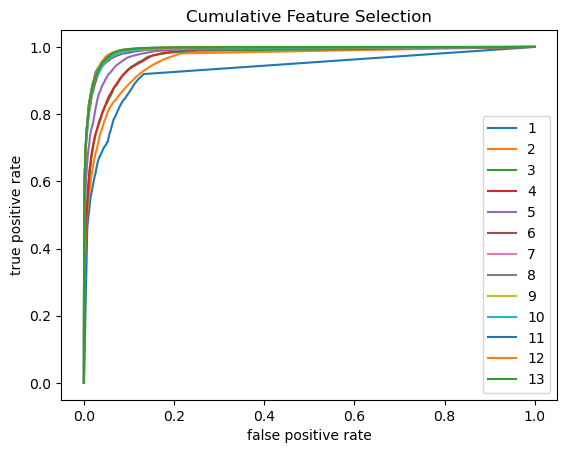

In [23]:
for i in range(13):   
    ranfor.fit(X_train.to_numpy()[:,12-i:13] ,Xtrain['det'])
    y_prob = ranfor.predict_proba(X_test.to_numpy()[:,12-i:13]) [:,1] 
    fpr, tpr, thresh = roc_curve(Xtest['det'], y_prob)
    plt.plot(fpr, tpr, label=str(i+1))
plt.legend()
plt.xlabel('false positive rate')
plt.ylabel('true positive rate')
plt.title('Cumulative Feature Selection')
plt.show()

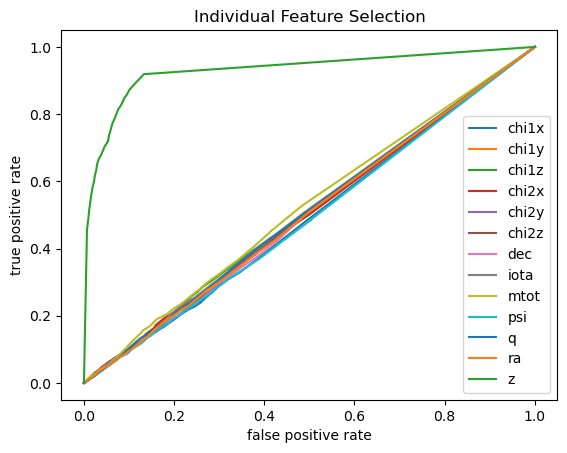

In [24]:
for i in range(13): 
    ranfor.fit(X_train.to_numpy()[:,i].reshape(-1,1) ,Xtrain['det'])
    y_prob = ranfor.predict_proba(X_test.to_numpy()[:,i].reshape(-1,1)) [:,1] 
    fpr, tpr, thresh = roc_curve(Xtest['det'], y_prob)
    plt.plot(fpr, tpr, label=keys[i])
plt.legend()
plt.xlabel('false positive rate')
plt.ylabel('true positive rate')
plt.title('Individual Feature Selection')
plt.show()

## Decision Tree and Bagging

In [32]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

tree_clf = DecisionTreeClassifier(random_state=42, max_depth=12, criterion='entropy')
tree_clf.fit(X_train, Xtrain['det'])

y_pred_tree = tree_clf.predict(X_test)

In [33]:
bag_clf = BaggingClassifier( DecisionTreeClassifier(random_state=42), n_estimators=500, max_samples=100, 
                            bootstrap=True, random_state=42, n_jobs=-1) #n_jobs=-1 says to use all the cores of your machine to do the job

%timeit bag_clf.fit(X_train, Xtrain['det'])

y_pred_bag = bag_clf.predict(X_test)

2.23 s ± 114 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [39]:
from sklearn.metrics import accuracy_score

C_tree = confusion_matrix(Xtest['det'], y_pred_tree)
C_bag = confusion_matrix(Xtest['det'], y_pred_bag)

print(accuracy_score(Xtest['det'], y_pred_tree))
print(C_tree)
print(np.sum(C_tree.diagonal())/len(Xtest['det']),'\n')
print(accuracy_score(Xtest['det'], y_pred_bag))
print(C_bag)
print(np.sum(C_bag.diagonal())/len(Xtest['det']))

0.9548
[[16661   417]
 [  487  2435]]
0.9548 

0.94325
[[16576   502]
 [  633  2289]]
0.94325


## Results

In [35]:
xlim = (0.0, 4.0)
ylim = (0, 1000)

xx, yy = np.meshgrid(np.linspace(xlim[0], xlim[1], 51), 
                     np.linspace(ylim[0], ylim[1], 51))
xystack = np.vstack([xx.ravel(),yy.ravel()])
Xgrid = xystack.T

X=Xtrain.get(['z','mtot'])
Xt=Xtest.get(['z','mtot'])

#random Forest
ranfor.fit(X,Xtrain['det'])
y_rf = ranfor.predict(Xt)
Z_rf = ranfor.predict(Xgrid)
Z_rf = Z_rf.reshape(xx.shape)

#Decisional Tree
tree_clf.fit(X, Xtrain['det'])
y_dt = tree_clf.predict(Xt)
Z_dt = tree_clf.predict(Xgrid)
Z_dt = Z_dt.reshape(xx.shape)

#Bagging
bag_clf.fit(X, Xtrain['det'])
y_bag = bag_clf.predict(Xt)
Z_bag = bag_clf.predict(Xgrid)
Z_bag = Z_bag.reshape(xx.shape)

C:\Users\balza\anaconda3copia\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\balza\anaconda3copia\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\balza\anaconda3copia\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but BaggingClassifier was fitted with feature names
  warnings.warn(


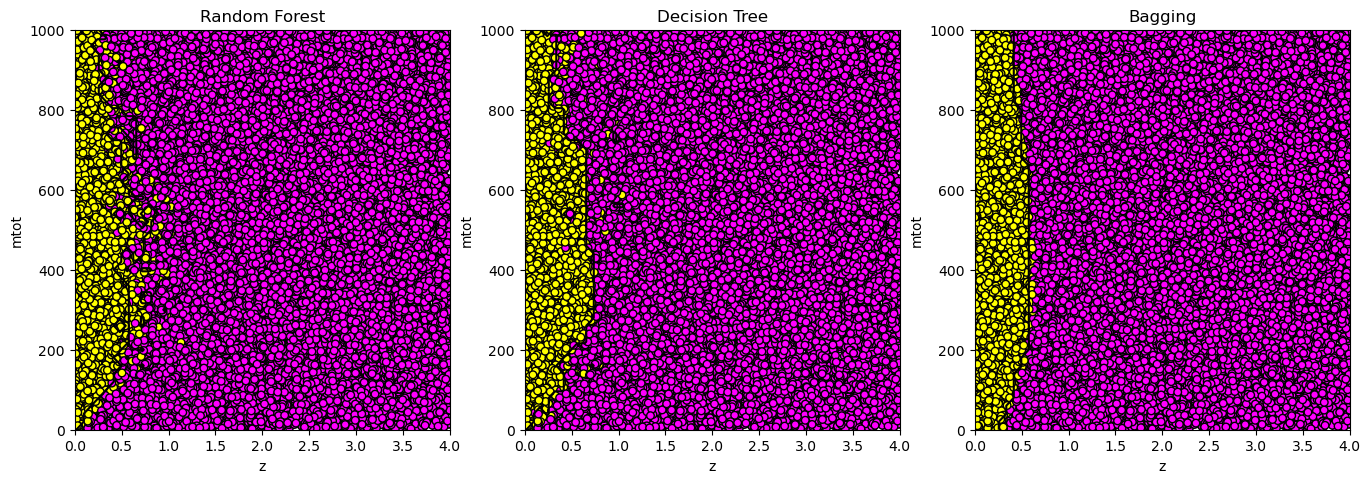

In [36]:
# plot the results
fig = plt.figure(figsize=(15, 5))
fig.subplots_adjust(bottom=0.15, top=0.95, hspace=0.0, left=0.1, right=0.95, wspace=0.2)

#data and decision boundary for RF
ax = fig.add_subplot(131)
im = ax.scatter(Xtest['z'], Xtest['mtot'], c=y_rf, s=30, cmap=plt.cm.spring, zorder=2, edgecolor='k')
ax.contour(xx, yy, Z_rf, [0.8], colors='k')
ax.set_xlabel('z')
ax.set_ylabel('mtot')
ax.set_title('Random Forest')

#data and decision boundary for DT
ax = fig.add_subplot(132)
im = ax.scatter(Xtest['z'], Xtest['mtot'], c=y_dt, s=30, cmap=plt.cm.spring, zorder=2, edgecolor='k')
ax.contour(xx, yy, Z_dt, [0.8], colors='k')
ax.set_xlabel('z')
ax.set_ylabel('mtot')
ax.set_title('Decision Tree')

#data and decision boundary for Bag
ax = fig.add_subplot(133)
im = ax.scatter(Xtest['z'], Xtest['mtot'], c=y_bag, s=30, cmap=plt.cm.spring, zorder=2, edgecolor='k')
ax.contour(xx, yy, Z_bag, [0.8], colors='k')
ax.set_xlabel('z')
ax.set_ylabel('mtot')
ax.set_title('Bagging')

plt.show()

## Completeness, Contamination and Accuracy

In [37]:
from astroML.utils import completeness_contamination
from sklearn.metrics import accuracy_score

n=3 #numer of used classifiers
preds = [y_dt,y_rf,y_bag]
comp_cont = np.zeros((2,n))
acc = np.zeros(n)

for i in range(3):
    comp_cont[0,i], comp_cont[1,i] = completeness_contamination(preds[i], Xtest['det'])
    acc[i] = accuracy_score(Xtest['det'], preds[i])
    print("Comp:", comp_cont[0,i], " Cont:", comp_cont[1,i], " Acc:", acc[i])

Comp: 0.7898699520876112  Cont: 0.17981520966595593  Acc: 0.944
Comp: 0.7772073921971252  Cont: 0.18132660418168708  Acc: 0.9423
Comp: 0.7778918548939083  Cont: 0.1474118529632408  Acc: 0.9479


## ROC curves for different classificators

In [25]:
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from astroML.classification import GMMBayes

from sklearn.metrics import roc_curve
from sklearn.metrics import precision_recall_curve

from astroML.utils import split_samples, completeness_contamination

In [28]:
from sklearn import preprocessing

train_scaler = preprocessing.StandardScaler().fit(X_train)
X_train_s = train_scaler.transform(X_train)

test_scaler = preprocessing.StandardScaler().fit(X_test)
Xtest_s = test_scaler.transform(X_test)

GaussianNB
LinearDiscriminantAnalysis
QuadraticDiscriminantAnalysis
LogisticRegression
KNeighborsClassifier
DecisionTreeClassifier
RandomForestClassifier
GMMBayes


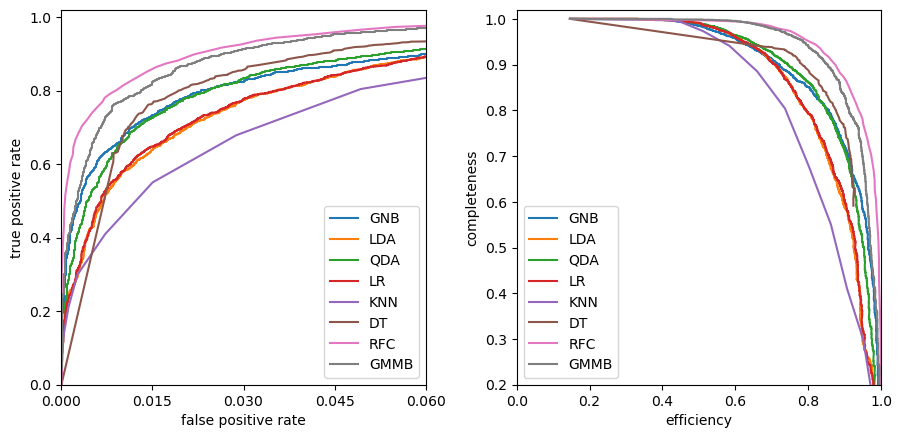

In [31]:
# Fit all the models to the training data
def compute_models(*args):
    names = []
    probs = []
    for classifier, kwargs in args:
        print(classifier.__name__)
        clf = classifier(**kwargs)
        clf.fit(X_train_s, Xtrain['det'])
        
        #Note that we are outputing the probabilities [of class 1], not the classes
        y_probs = clf.predict_proba(X_test_s)[:, 1]

        names.append(classifier.__name__)
        probs.append(y_probs)

    return names, probs

names, probs = compute_models((GaussianNB, {}),
                              (LinearDiscriminantAnalysis, {}),
                              (QuadraticDiscriminantAnalysis, {}),
                              (LogisticRegression, dict(class_weight='balanced')),
                              (KNeighborsClassifier, dict(n_neighbors=20)),
                              (DecisionTreeClassifier, dict(random_state=42, max_depth=12, criterion='entropy')),
                              (RandomForestClassifier, dict(n_estimators=opt_n)),
                              (GMMBayes, dict(n_components=3, tol=1E-5, covariance_type='full')))

# Plot ROC curves and completeness/efficiency
fig = plt.figure(figsize=(15, 5))
fig.subplots_adjust(left=0.1, right=0.95, bottom=0.15, top=0.9, wspace=0.25)

# ax1 will show roc curves
ax1 = plt.subplot(131)

# ax2 will show completeness/efficiency
ax2 = plt.subplot(132)

# ax3 will show precision/recall
# ax3 = plt.subplot(133)

labels = dict(GaussianNB='GNB',
              LinearDiscriminantAnalysis='LDA',
              QuadraticDiscriminantAnalysis='QDA',
              KNeighborsClassifier='KNN',
              DecisionTreeClassifier='DT',
              RandomForestClassifier='RFC',
              GMMBayes='GMMB',
              LogisticRegression='LR')

thresholds = np.linspace(0, 1, 50001)[:-1]

# iterate through and show results
for name, y_prob in zip(names, probs):
    fpr, tpr, thresh = roc_curve(Xtest['det'], y_prob)
    precision, recall, thresh2 = precision_recall_curve(Xtest['det'], y_prob)

    # add (0, 0) as first point
    fpr = np.concatenate([[0], fpr])
    tpr = np.concatenate([[0], tpr])
    # Here we add (1,0) 
    precision = np.concatenate([[0], precision])
    recall = np.concatenate([[1], recall])
    thresh2 = np.concatenate([[0], thresh2])

    ax1.plot(fpr, tpr, label=labels[name])

    #See note above about astroML vs. sklearn
    #Note that the range of threshhold values here is 0% to 100% (0.0 to 1.0)
    comp = np.zeros_like(thresholds)
    cont = np.zeros_like(thresholds)
    for i, t in enumerate(thresholds):
        y_pred = (y_prob >= t)
        comp[i], cont[i] = completeness_contamination(y_pred, Xtest['det'])
    ax2.plot(1 - cont, comp, label=labels[name])
    
    #ax3.plot(precision, recall, label=labels[name])

ax1.set_xlim(0, 0.06)
ax1.set_ylim(0, 1.02)
ax1.xaxis.set_major_locator(plt.MaxNLocator(5))
ax1.set_xlabel('false positive rate')
ax1.set_ylabel('true positive rate')
ax1.legend(loc=4)

ax2.set_xlabel('efficiency')
ax2.set_ylabel('completeness')
ax2.set_xlim(0, 1.0)
ax2.set_ylim(0.2, 1.02)
ax2.legend()

#ax3.set_xlabel('precision')
#ax3.set_ylabel('recall')
#ax3.set_xlim(0, 1.0)
#ax3.set_ylim(0.2, 1.02)

plt.show()